# Seasonal Agriculture Performance Analysis

## 1. Introduction

This project analyzes agricultural activities across different seasons,
geographical areas, farming practices, environmental conditions,
resource usage, production, and economic performance.

The primary objective is to identify seasonal patterns,
relationships, variations, and meaningful insights from the dataset.

## 2. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Loading the Dataset

In [2]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (2).csv')


## 4. Initial Dataset Exploration

### 4.1 First Five Rows
### 4.2 Dataset Shape
### 4.3 Column Names
### 4.4 Data Types
### 4.5 Dataset Information
### 4.6 Descriptive Statistics

In [3]:
df.head()
df.shape
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 4000
Number of Columns: 28


In [4]:
df.columns
df.dtypes


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## 4. Data Quality Assessment and Cleaning

### 4.1 Checking Missing Values

Before performing analysis, we check the dataset for missing values
to understand whether any variables contain incomplete observations.


In [7]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


### 4.2 Missing Value Percentage

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0
Rainfall_mm,1.2
Soil_Moisture_pct,1.0
Yield_Tonnes_Ha,0.8


 4.3 Check visual of missing value


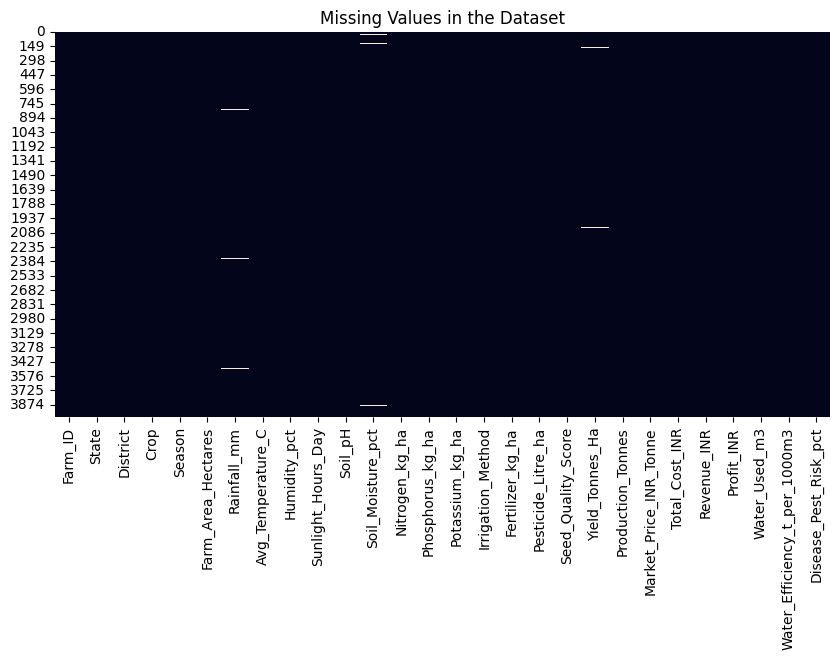

In [9]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in the Dataset")
plt.show()

4.4  handle Missing Values

In [11]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df['Rainfall_mm'].median()
)

In [10]:
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

In [12]:
df[df['Yield_Tonnes_Ha'].isnull()]

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
55,SF10056,Karnataka,Warangal,Groundnut,Rabi,11.70,167.3,26.2,62.4,6.8,...,0.94,NaN,19.42,50837,780159,987255,207096,4665,4.163,39.4
163,SF10164,Madhya Pradesh,Erode,Pulses,Zaid,3.55,445.9,29.7,61.1,8.2,...,0.89,NaN,1.06,58920,206701,62455,-144246,1837,0.577,44.3
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
648,SF10649,Andhra Pradesh,Krishna,Groundnut,Rabi,6.14,423.1,22.2,53.4,7.0,...,0.86,NaN,8.66,61086,386561,529005,142444,3692,2.346,31.2
650,SF10651,Gujarat,Raichur,Maize,Rabi,13.23,587.6,24.7,59.3,8.4,...,0.76,NaN,11.77,21564,1065547,253808,-811739,9310,1.264,52.4
777,SF10778,Gujarat,Ludhiana,Cotton,Rabi,1.83,502.1,19.3,42.3,7.2,...,0.86,NaN,2.42,76135,144893,184247,39354,1275,1.898,47.2
874,SF10875,Karnataka,Erode,Rice,Kharif,3.15,985.1,26.9,58.8,6.6,...,0.85,NaN,3.87,16937,226859,65546,-161313,5929,0.653,48.9
899,SF10900,Tamil Nadu,Guntur,Pulses,Rabi,6.65,677.3,19.9,52.5,7.3,...,0.76,NaN,6.38,72393,450014,461867,11853,2857,2.233,34.1
1133,SF11134,Karnataka,Raichur,Cotton,Kharif,10.89,853.7,32.7,68.0,7.9,...,0.83,NaN,15.46,68953,665642,1066013,400371,10950,1.412,47.4
1251,SF11252,Telangana,Warangal,Chilli,Zaid,9.92,151.5,31.8,50.5,8.5,...,0.98,NaN,12.20,108639,791746,1325396,533650,7012,1.740,46.4


In [13]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [14]:
df_clean = df.copy()

In [15]:
df_clean.duplicated().sum()

np.int64(0)

In [16]:
df_clean[df_clean.duplicated()]

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct


No duplicate records were identified in the dataset. Therefore,
no duplicate rows were removed.

In [17]:
df_clean = df_clean.drop_duplicates()

### 4.4 Data Type Validation

In [18]:
df_clean.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [19]:
df_clean.select_dtypes(include=np.number).columns

Index(['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C',
       'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
       'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [20]:
print("Seasons:")
print(df_clean['Season'].unique())

Seasons:
['Kharif' 'Rabi' 'Zaid']


In [21]:
print("Crops:")
print(df_clean['Crop'].unique())

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']


In [22]:
print("Irrigation Methods:")
print(df_clean['Irrigation_Method'].unique())

Irrigation Methods:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [23]:
df_clean['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [24]:
df_clean['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [25]:
df_clean['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [26]:
print("Dataset Shape:", df_clean.shape)

print("\nTotal Missing Values:",
      df_clean.isnull().sum().sum())

print("\nTotal Duplicate Rows:",
      df_clean.duplicated().sum())

Dataset Shape: (4000, 28)

Total Missing Values: 32

Total Duplicate Rows: 0


In [27]:
df[df['Yield_Tonnes_Ha'].isnull()]

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
55,SF10056,Karnataka,Warangal,Groundnut,Rabi,11.70,167.3,26.2,62.4,6.8,...,0.94,NaN,19.42,50837,780159,987255,207096,4665,4.163,39.4
163,SF10164,Madhya Pradesh,Erode,Pulses,Zaid,3.55,445.9,29.7,61.1,8.2,...,0.89,NaN,1.06,58920,206701,62455,-144246,1837,0.577,44.3
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
648,SF10649,Andhra Pradesh,Krishna,Groundnut,Rabi,6.14,423.1,22.2,53.4,7.0,...,0.86,NaN,8.66,61086,386561,529005,142444,3692,2.346,31.2
650,SF10651,Gujarat,Raichur,Maize,Rabi,13.23,587.6,24.7,59.3,8.4,...,0.76,NaN,11.77,21564,1065547,253808,-811739,9310,1.264,52.4
777,SF10778,Gujarat,Ludhiana,Cotton,Rabi,1.83,502.1,19.3,42.3,7.2,...,0.86,NaN,2.42,76135,144893,184247,39354,1275,1.898,47.2
874,SF10875,Karnataka,Erode,Rice,Kharif,3.15,985.1,26.9,58.8,6.6,...,0.85,NaN,3.87,16937,226859,65546,-161313,5929,0.653,48.9
899,SF10900,Tamil Nadu,Guntur,Pulses,Rabi,6.65,677.3,19.9,52.5,7.3,...,0.76,NaN,6.38,72393,450014,461867,11853,2857,2.233,34.1
1133,SF11134,Karnataka,Raichur,Cotton,Kharif,10.89,853.7,32.7,68.0,7.9,...,0.83,NaN,15.46,68953,665642,1066013,400371,10950,1.412,47.4
1251,SF11252,Telangana,Warangal,Chilli,Zaid,9.92,151.5,31.8,50.5,8.5,...,0.98,NaN,12.20,108639,791746,1325396,533650,7012,1.740,46.4


In [28]:
df['Yield_Tonnes_Ha'].isnull().sum()

np.int64(32)

In [29]:
df = df.dropna(subset=['Yield_Tonnes_Ha'])
df['Yield_Tonnes_Ha'].isnull().sum()

np.int64(0)

Handling Missing Values in Yield

The Yield_Tonnes_Ha column contained 32 missing values, representing only 0.8% of the dataset. Since yield is a key outcome variable for agricultural performance analysis, the missing values were not imputed using mean or median values. Instead, the 32 records were removed to avoid introducing artificial yield values into subsequent analysis.

In [30]:
df.shape


(3968, 28)

## 6. Outlier Investigation

Outliers are unusually high or low values that may affect statistical analysis.
Boxplots are used to visually identify potential outliers.

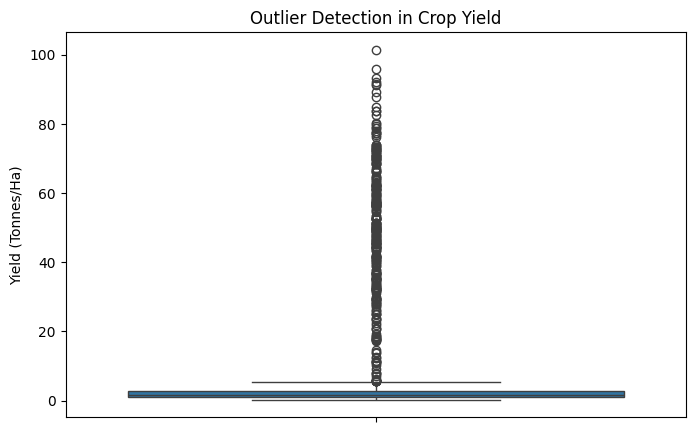

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Yield_Tonnes_Ha'])
plt.title('Outlier Detection in Crop Yield')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

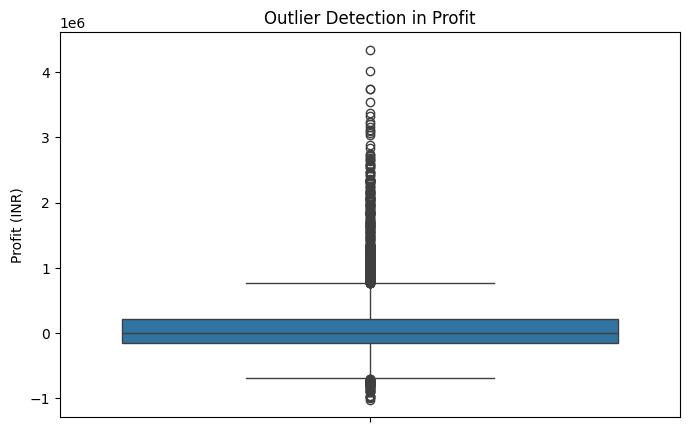

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df['Profit_INR'])

plt.title('Outlier Detection in Profit')
plt.ylabel('Profit (INR)')

plt.show()

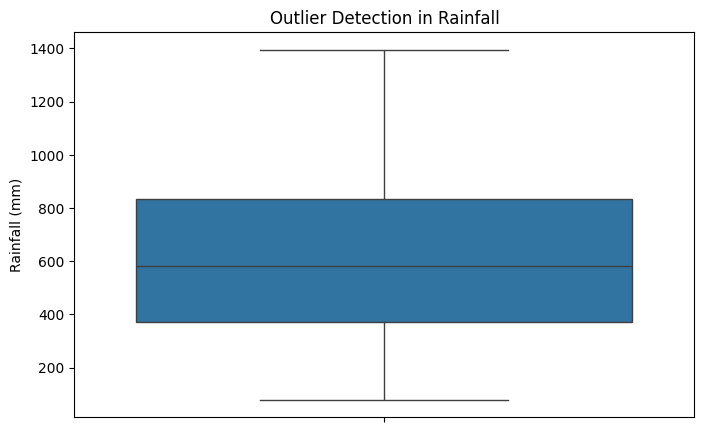

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df['Rainfall_mm'])

plt.title('Outlier Detection in Rainfall')
plt.ylabel('Rainfall (mm)')

plt.show()

In [34]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df[
    (df['Yield_Tonnes_Ha'] < lower_bound) |
    (df['Yield_Tonnes_Ha'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Potential Outliers:", len(yield_outliers))

Lower Bound: -1.6349999999999996
Upper Bound: 5.5249999999999995
Number of Potential Outliers: 302


## 7. Univariate Analysis

Univariate analysis examines one variable at a time to understand its
distribution and frequency.

In [35]:
df['Crop'].value_counts()

,count
Crop,
Rice,682
Wheat,612
Maize,547
Cotton,504
Pulses,494
Groundnut,419
Chilli,407
Sugarcane,303


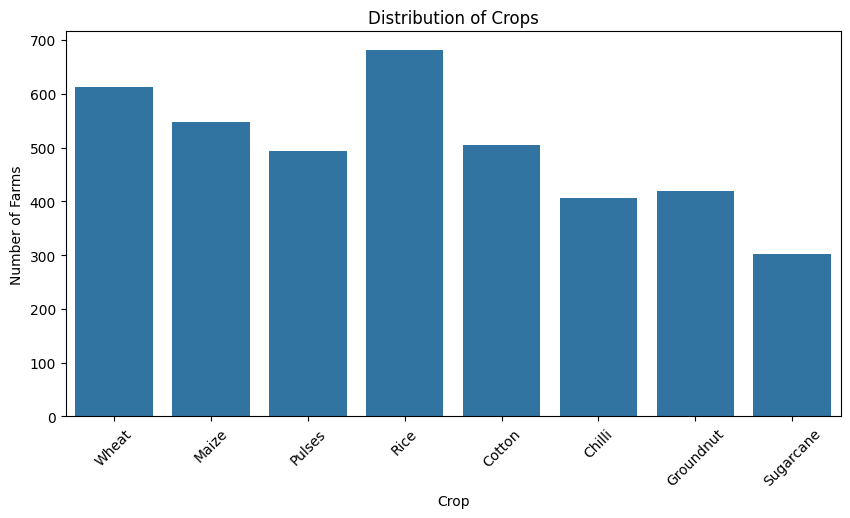

In [36]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='Crop')

plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)

plt.show()

In [37]:
df['Season'].value_counts()

,count
Season,
Kharif,1772
Rabi,1607
Zaid,589


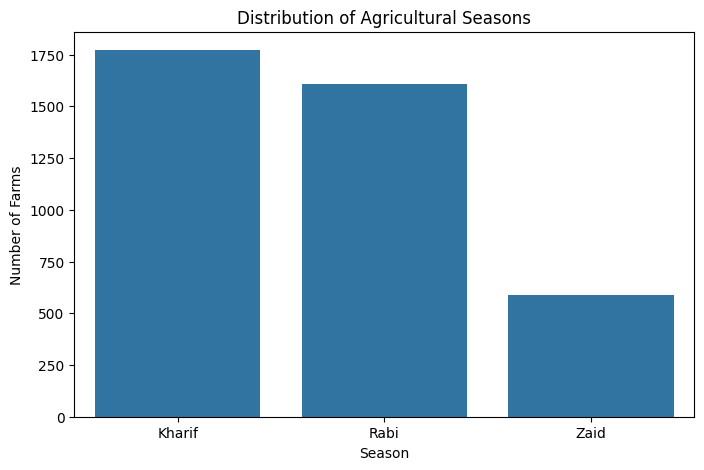

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Season')

plt.title('Distribution of Agricultural Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

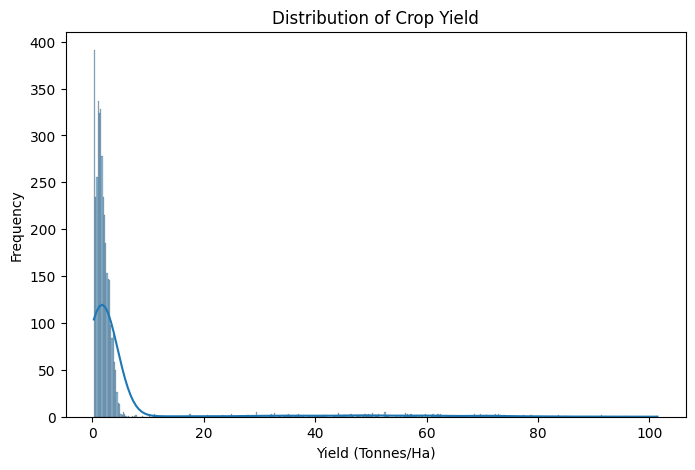

In [39]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Yield_Tonnes_Ha'], kde=True)

plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')

plt.show()

In [40]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.643973
Rabi,5.080498
Zaid,4.665942


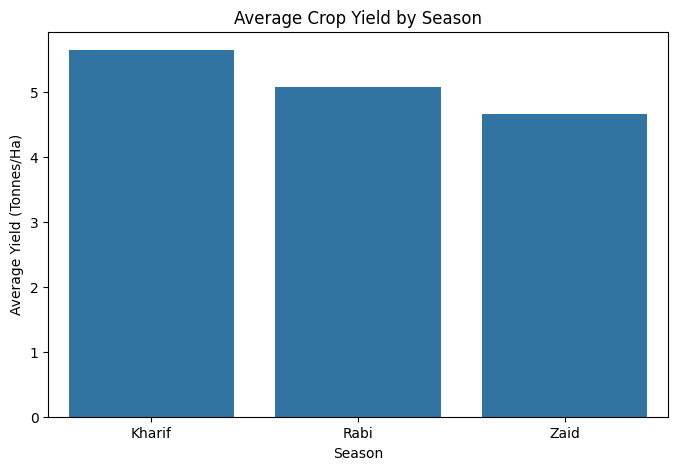

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(x=season_yield.index, y=season_yield.values)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

Season vs Profit

In [42]:

season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

season_profit

,Profit_INR
Season,
Kharif,179367.124718
Rabi,88197.251400
Zaid,-26592.397284


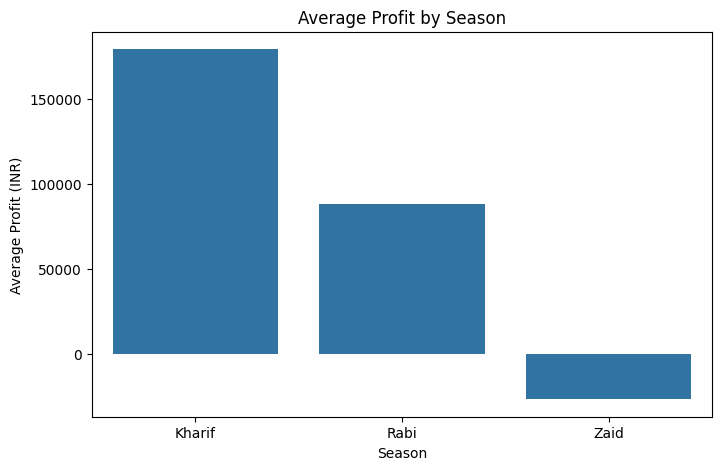

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(x=season_profit.index, y=season_profit.values)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

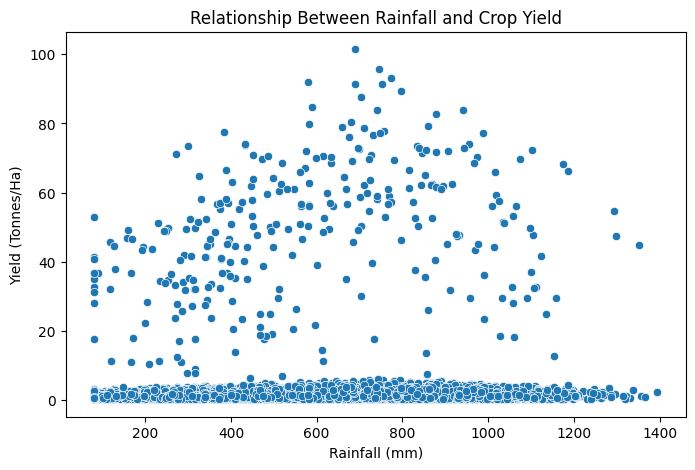

In [44]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Relationship Between Rainfall and Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

Fertilizer vs Yield

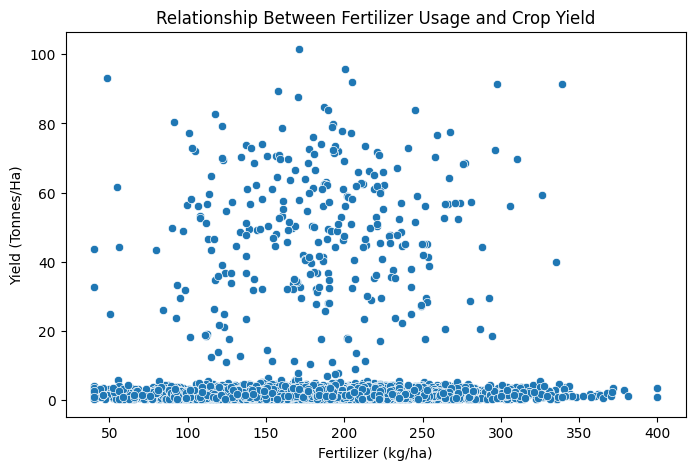

In [45]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha'
)

plt.title('Relationship Between Fertilizer Usage and Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

Water Efficiency vs Profit

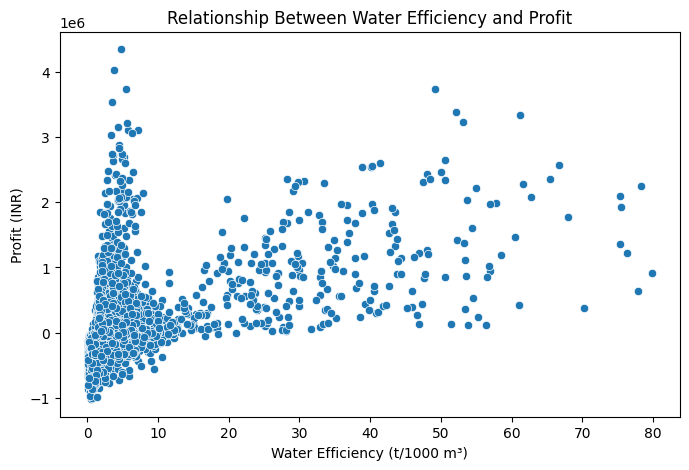

In [46]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Water_Efficiency_t_per_1000m3',
    y='Profit_INR'
)

plt.title('Relationship Between Water Efficiency and Profit')
plt.xlabel('Water Efficiency (t/1000 m³)')
plt.ylabel('Profit (INR)')

plt.show()

### 8.2 Seasonal Profit Comparison

This analysis compares the average profit across different agricultural
seasons to understand seasonal differences in economic performance.

In [47]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

season_profit

,Profit_INR
Season,
Kharif,179367.124718
Rabi,88197.251400
Zaid,-26592.397284


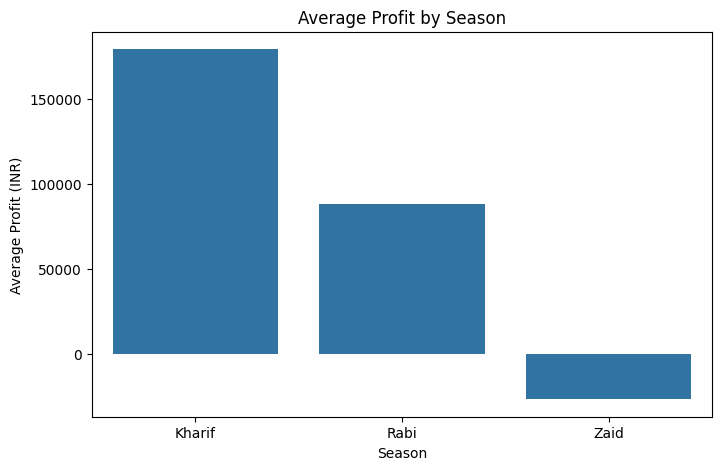

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(x=season_profit.index, y=season_profit.values)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

### 8.3 Rainfall and Crop Yield Relationship

This analysis examines the relationship between rainfall and crop yield
to understand whether changes in rainfall are associated with variations
in agricultural productivity.

In [54]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [55]:
rainfall_yield_corr = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

rainfall_yield_corr

np.float64(0.03054528078188267)

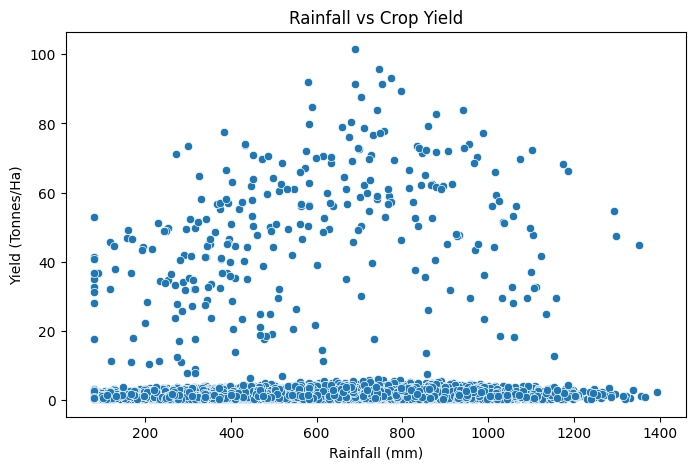

In [56]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    data=df
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

### 8.4 Fertilizer Usage and Crop Yield Relationship

This analysis examines the relationship between fertilizer usage and crop
yield to understand whether fertilizer application is associated with
changes in agricultural productivity.

In [57]:
fertilizer_yield_corr = df['Fertilizer_kg_ha'].corr(df['Yield_Tonnes_Ha'])

fertilizer_yield_corr

np.float64(0.0005618892795134815)

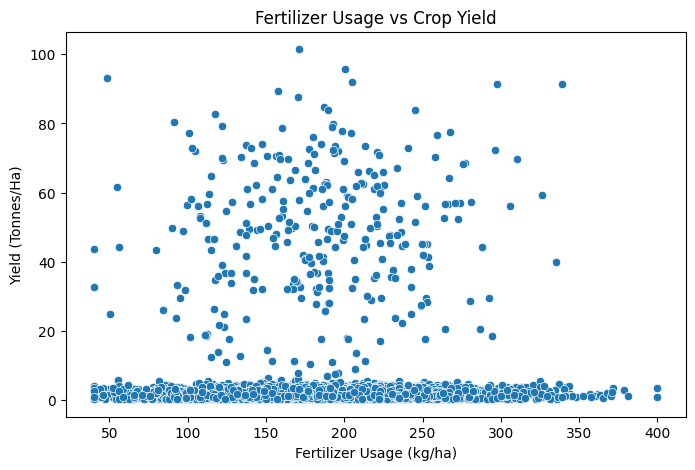

In [58]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    data=df
)

plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer Usage (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

### 8.5 Water Efficiency and Profit Relationship

This analysis examines the relationship between water efficiency and profit
to understand whether efficient use of water resources is associated with
better economic performance.

In [59]:
water_profit_corr = df['Water_Efficiency_t_per_1000m3'].corr(df['Profit_INR'])

water_profit_corr

np.float64(0.48956461405832385)

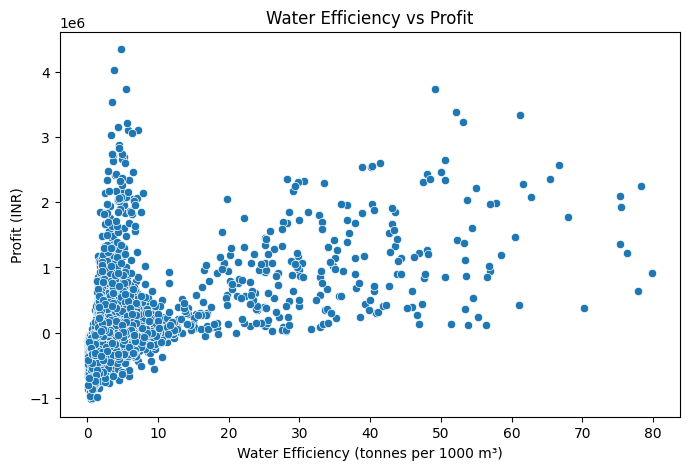

In [60]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Water_Efficiency_t_per_1000m3',
    y='Profit_INR',
    data=df
)

plt.title('Water Efficiency vs Profit')
plt.xlabel('Water Efficiency (tonnes per 1000 m³)')
plt.ylabel('Profit (INR)')

plt.show()


## 9. Multivariate Analysis

This analysis examines the combined relationship between season, rainfall,
and crop yield to identify how agricultural productivity varies under
different seasonal and rainfall conditions.

In [61]:
season_rainfall_yield = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).sort_values('Yield_Tonnes_Ha', ascending=False)

season_rainfall_yield

,Rainfall_mm,Yield_Tonnes_Ha
Season,,
Kharif,848.690293,5.643973
Rabi,437.928625,5.080498
Zaid,304.251613,4.665942


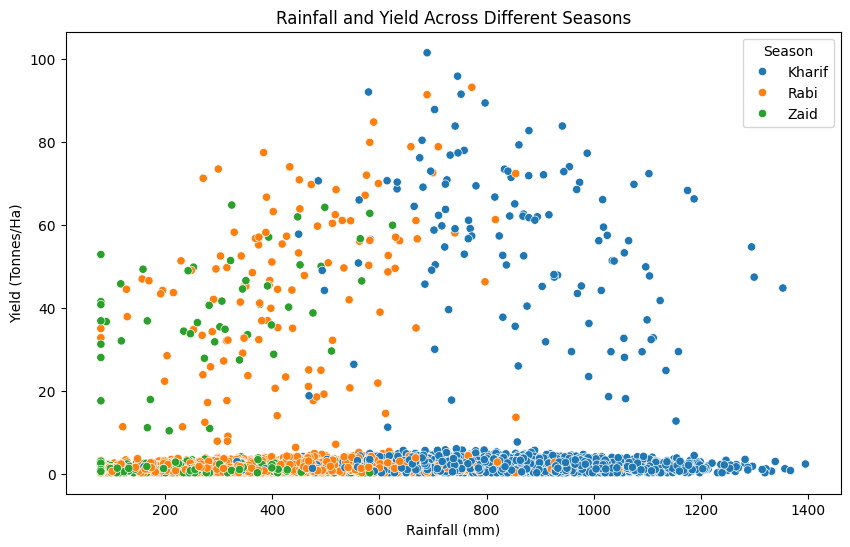

In [62]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall and Yield Across Different Seasons')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season')

plt.show()

### 9.2 Seasonal Fertilizer Usage and Crop Yield

This analysis compares fertilizer usage and crop yield across different
seasons to understand whether seasonal differences in fertilizer application
are associated with variations in agricultural productivity.

In [63]:
season_fertilizer_yield = df.groupby('Season').agg({
    'Fertilizer_kg_ha': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).sort_values('Yield_Tonnes_Ha', ascending=False)

season_fertilizer_yield

,Fertilizer_kg_ha,Yield_Tonnes_Ha
Season,,
Kharif,187.041027,5.643973
Rabi,185.282016,5.080498
Zaid,184.233447,4.665942


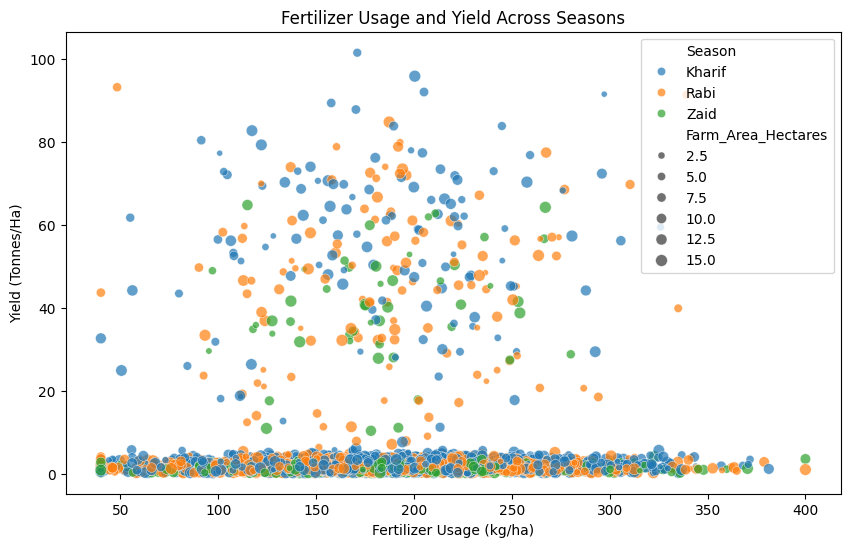

In [64]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season',
    size='Farm_Area_Hectares',
    alpha=0.7
)

plt.title('Fertilizer Usage and Yield Across Seasons')
plt.xlabel('Fertilizer Usage (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

### 9.3 Seasonal Water Efficiency and Profit

This analysis examines water efficiency and profit across different seasons
to understand whether efficient water usage is associated with better
economic performance under different seasonal conditions.

In [65]:
season_water_profit = df.groupby('Season').agg({
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
}).sort_values('Profit_INR', ascending=False)

season_water_profit

,Water_Efficiency_t_per_1000m3,Profit_INR
Season,,
Kharif,5.906584,179367.124718
Rabi,5.178462,88197.251400
Zaid,4.440922,-26592.397284


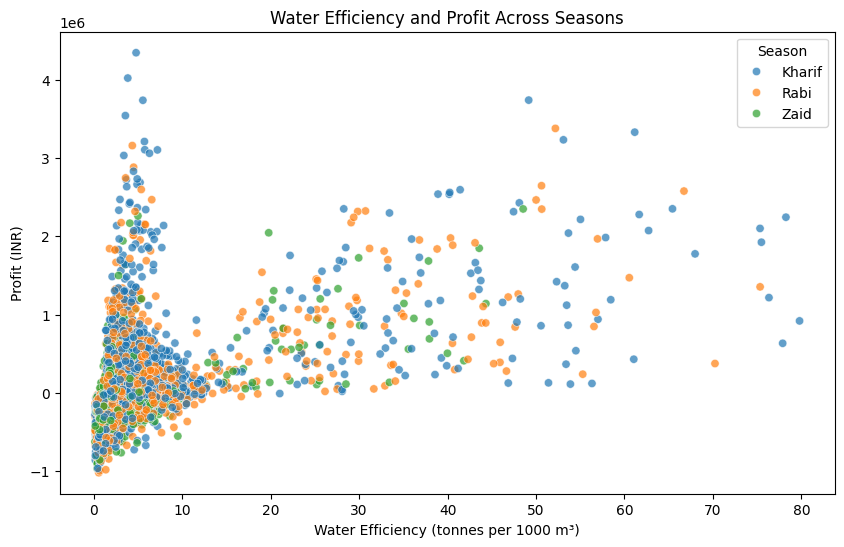

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Water_Efficiency_t_per_1000m3',
    y='Profit_INR',
    hue='Season',
    alpha=0.7
)

plt.title('Water Efficiency and Profit Across Seasons')
plt.xlabel('Water Efficiency (tonnes per 1000 m³)')
plt.ylabel('Profit (INR)')

plt.show()

## 10. Correlation Analysis

Correlation analysis is used to examine the strength and direction of
relationships between important numerical variables in the agricultural
dataset.

In [67]:
corr_matrix = df[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Soil_Moisture_pct',
        'Fertilizer_kg_ha',
        'Yield_Tonnes_Ha',
        'Revenue_INR',
        'Profit_INR',
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3'
    ]
].corr()

corr_matrix


,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Fertilizer_kg_ha,Yield_Tonnes_Ha,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Rainfall_mm,1.000000,0.196972,0.509395,0.025229,0.030545,0.099969,0.109104,0.002877,0.059823
Avg_Temperature_C,0.196972,1.000000,0.081029,0.014632,0.009349,0.024090,0.006613,0.022794,0.006592
Soil_Moisture_pct,0.509395,0.081029,1.000000,0.009431,0.010119,0.080025,0.092481,0.002741,0.027742
Fertilizer_kg_ha,0.025229,0.014632,0.009431,1.000000,0.000562,0.004264,-0.073645,0.000210,0.005928
Yield_Tonnes_Ha,0.030545,0.009349,0.010119,0.000562,1.000000,0.433648,0.489822,0.388653,0.915438
Revenue_INR,0.099969,0.024090,0.080025,0.004264,0.433648,1.000000,0.887644,0.429460,0.428261
Profit_INR,0.109104,0.006613,0.092481,-0.073645,0.489822,0.887644,1.000000,0.191610,0.489565
Water_Used_m3,0.002877,0.022794,0.002741,0.000210,0.388653,0.429460,0.191610,1.000000,0.217660
Water_Efficiency_t_per_1000m3,0.059823,0.006592,0.027742,0.005928,0.915438,0.428261,0.489565,0.217660,1.000000


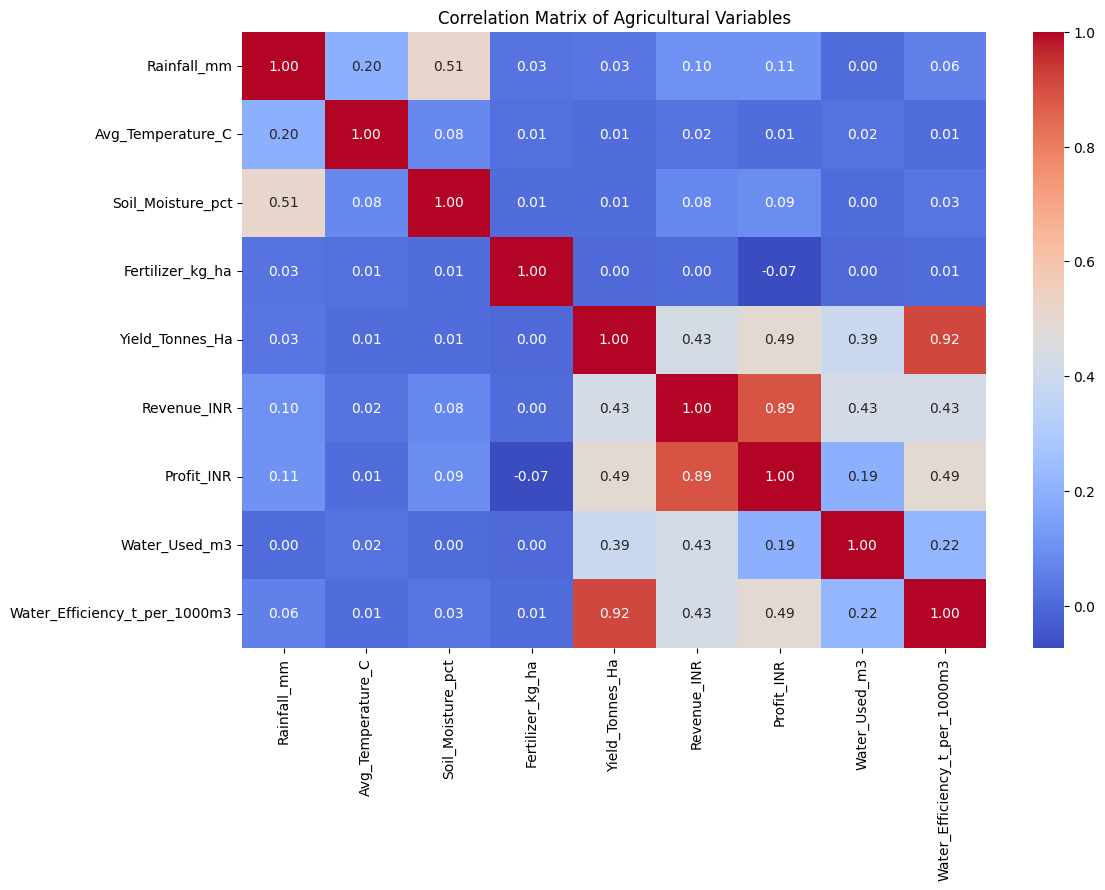

In [68]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.show()

## 11.1 Crop-wise Yield Analysis

This analysis compares the average yield across different crops to identify
which crops show better agricultural productivity in the given dataset.

In [69]:
crop_yield = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
      .mean()
      .sort_values(ascending=False)
)

crop_yield

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.938746
Maize,2.717130
Rice,2.439413
Wheat,2.109216
Chilli,1.540344
Groundnut,1.317924
Cotton,1.225734
Pulses,0.918198


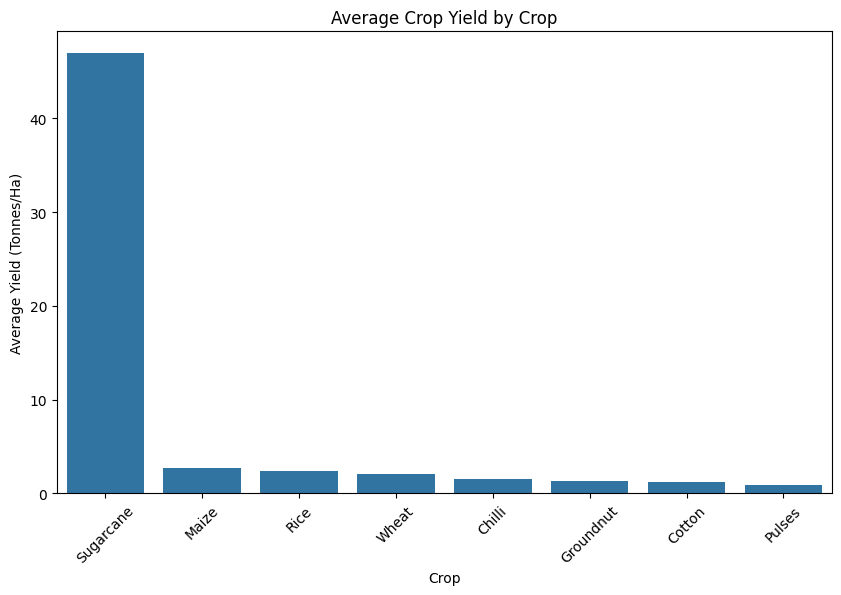

In [70]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_yield.index,
    y=crop_yield.values
)

plt.title('Average Crop Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)

plt.show()

## 11.2 State-wise Profit Analysis

This analysis compares the average profit across different states to identify
regional differences in agricultural economic performance.

In [71]:
state_profit = (
    df.groupby('State')['Profit_INR']
      .mean()
      .sort_values(ascending=False)
)

state_profit

,Profit_INR
State,
Maharashtra,136874.135294
Punjab,136025.636364
Gujarat,120050.958592
Tamil Nadu,119117.817048
Karnataka,118495.573499
Telangana,108282.060665
Madhya Pradesh,89479.767821
Andhra Pradesh,69497.228571


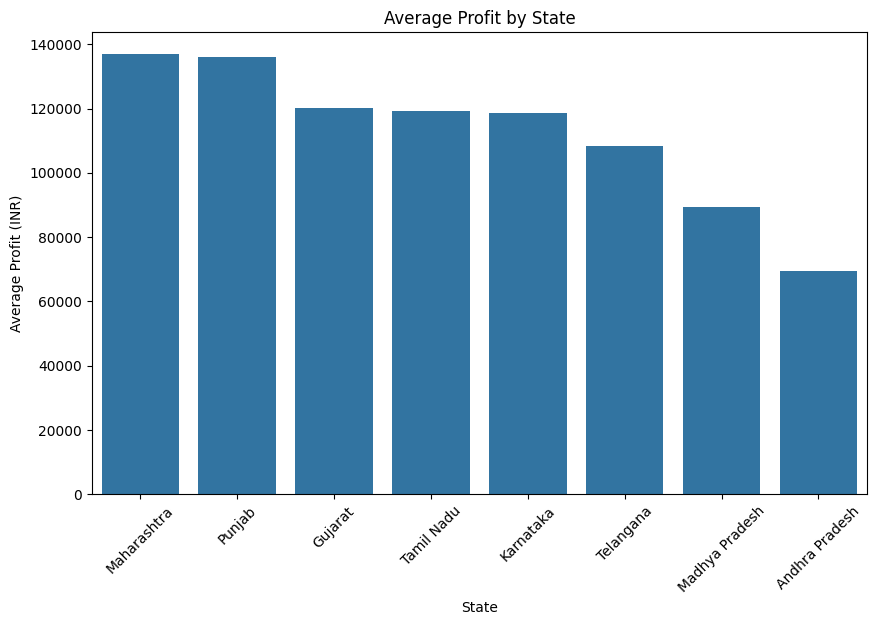

In [73]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_profit.index,
    y=state_profit.values
)

plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.show()

## 11.3 Irrigation Method and Water Efficiency Analysis

This analysis compares the average water efficiency across different
irrigation methods to identify differences in resource utilization.

In [74]:
irrigation_efficiency = (
    df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3']
      .mean()
      .sort_values(ascending=False)
)

irrigation_efficiency

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.573185
Drip,6.227752
Sprinkler,4.693999
Flood,3.460465


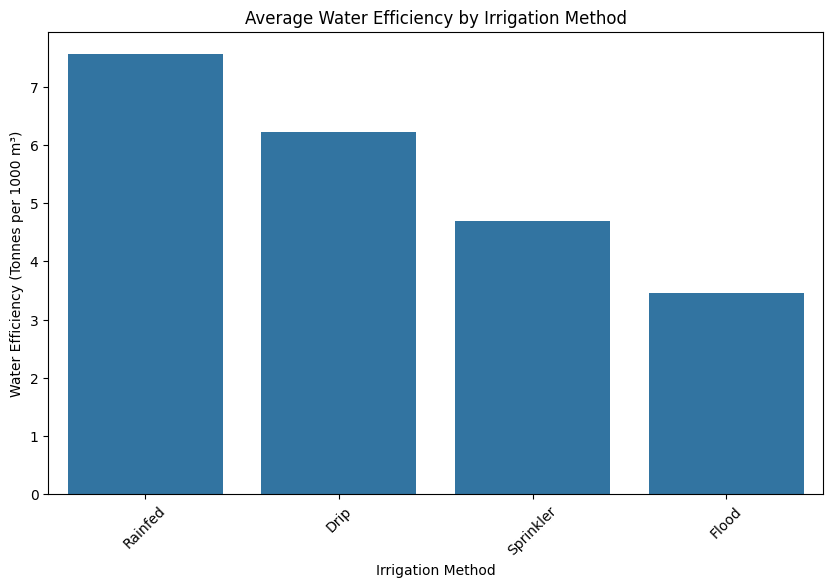

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=irrigation_efficiency.index,
    y=irrigation_efficiency.values
)

plt.title('Average Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.xticks(rotation=45)

plt.show()

## 12. Key Findings and Meaningful Insights

The following insights summarize the major patterns and relationships
identified during the analysis of seasonal agricultural performance.

In [76]:
print("1. Highest Average Yield Season:")
print(season_yield.idxmax(), "->", round(season_yield.max(), 2))

print("\n2. Highest Average Profit Season:")
print(season_profit.idxmax(), "->", round(season_profit.max(), 2))

print("\n3. Rainfall-Yield Correlation:")
print(round(rainfall_yield_corr, 3))

print("\n4. Fertilizer-Yield Correlation:")
print(round(fertilizer_yield_corr, 3))

print("\n5. Water Efficiency-Profit Correlation:")
print(round(water_profit_corr, 3))

print("\n6. Highest Yield Crop:")
print(crop_yield.idxmax(), "->", round(crop_yield.max(), 2))

print("\n7. Highest Profit State:")
print(state_profit.idxmax(), "->", round(state_profit.max(), 2))

print("\n8. Most Water-Efficient Irrigation Method:")
print(irrigation_efficiency.idxmax(), "->",
      round(irrigation_efficiency.max(), 2))

1. Highest Average Yield Season:
Kharif -> 5.64

2. Highest Average Profit Season:
Kharif -> 179367.12

3. Rainfall-Yield Correlation:
0.031

4. Fertilizer-Yield Correlation:
0.001

5. Water Efficiency-Profit Correlation:
0.49

6. Highest Yield Crop:
Sugarcane -> 46.94

7. Highest Profit State:
Maharashtra -> 136874.14

8. Most Water-Efficient Irrigation Method:
Rainfed -> 7.57


## 13. Recommendations

Based on the findings from seasonal, environmental, resource, and economic
analysis, the following recommendations can be made:

1. Farmers should consider seasonal variations in agricultural planning
   because crop performance differs across seasons.

2. Water resources should be managed efficiently, as water efficiency
   shows a strong relationship with crop yield and can contribute to
   better resource utilization.

3. Irrigation methods with higher water efficiency should be considered
   where suitable for local farming conditions.

4. Rainfall and soil moisture conditions should be monitored while
   planning irrigation and crop activities.

5. Crop selection can be guided by the observed differences in average
   yield among crops.

6. Regional differences in agricultural profit should be considered
   while planning farming strategies.

7. Fertilizer application should be optimized according to crop and
   seasonal requirements rather than assuming that higher fertilizer
   usage always results in higher yield.

8. Agricultural decisions should be supported by data-driven analysis
   of yield, resource usage, costs, revenue, and profit.

## 14. Limitations

The following limitations should be considered while interpreting the
results of this analysis:

1. The analysis is based only on the variables available in the given
   dataset.

2. The dataset represents specific farming conditions and may not fully
   represent agricultural conditions in all regions.

3. Correlation analysis identifies relationships between variables but
   does not establish causal relationships.

4. Seasonal patterns observed in the dataset may not remain the same
   under different environmental or market conditions.

5. The analysis is based on historical observations and therefore may
   not accurately predict future agricultural performance.

6. Some important external factors, such as government policies,
   extreme weather events, and changes in market demand, may not be
   represented in the dataset.

7. The findings should therefore be interpreted as data-driven
   observations rather than universal agricultural rules.

## 15. Conclusion

This project analyzed agricultural performance across different seasons,
regions, crops, environmental conditions, resource usage, and economic
factors. The analysis included data cleaning, descriptive statistics,
univariate analysis, bivariate analysis, multivariate analysis, seasonal
comparisons, and correlation analysis.

The study helped identify important patterns in crop yield, profit,
rainfall, fertilizer usage, water usage, and water efficiency. The
analysis also highlighted differences in agricultural performance across
seasons, crops, states, and irrigation methods.

The findings demonstrate how data analytics can be used to understand
seasonal agricultural patterns, identify relationships between farming
conditions and outcomes, and support evidence-based agricultural planning.

Overall, the project provides data-driven insights into agricultural
performance and demonstrates the usefulness of analytical and
visualization techniques for understanding real-world agricultural data.